#### Imports


In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 11.8
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys

In [4]:
sys.path.append('C:/Users/rishe/minor_project_rl')
sys.path.append('C:/Users/rishe/minor_project_rl/scde')

In [5]:
from scde.utils.config import load_config
from scde.envs.vec_env import make_vec_env
from scde.models.actor_critic import ActorCritic
from scde.ppo.rollout_buffer import RolloutBuffer
from scde.ppo.updater import PPOUpdater

#### Load the config

In [6]:
proj_root_path = 'C:/Users/rishe/minor_project_rl'

In [7]:
config_path = f'{proj_root_path}/scde/configs/b1_ppo_only.yaml'
cfg = load_config(config_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(cfg)

{'env_id': 'MiniGrid-FourRooms-v0', 'n_envs': 16, 'total_steps': 2000000, 'n_steps': 128, 'batch_size': 256, 'n_epochs': 4, 'gamma': 0.999, 'gamma_int': 0.99, 'gae_lambda': 0.95, 'clip_eps': 0.2, 'lr': 0.0003, 'entropy_coef': 0.01, 'value_coef': 0.5, 'max_grad_norm': 0.5, 'feature_dim': 256, 'action_dim': 7, 'use_rnd': False, 'rnd_dim': 512, 'rnd_update_proportion': 0.25, 'use_clip': False, 'clip_model': 'ViT-B-32', 'semantic_k': 5, 'buffer_size': 50000, 'norm_tau': 0.001, 'norm_clip': 5.0, 'adaptive': False, 'alpha': 1.0, 'beta': 0.5, 'alpha_max': 1.0, 'alpha_min': 0.05, 'beta_max': 0.5, 'beta_min': 0.01, 'tau_rho': 0.01, 'wandb': True, 'project_name': 'scde', 'run_name': 'B1_PPO_only', 'defaults': ['base']}


In [8]:
envs = make_vec_env(cfg.env_id, cfg.n_envs)

model = ActorCritic(
    feature_dim=cfg.feature_dim,
    action_dim=cfg.action_dim
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

buffer = RolloutBuffer(cfg.n_steps, cfg.n_envs, device=device)

updater = PPOUpdater(
    model,
    optimizer,
    clip_eps=cfg.clip_eps,
    value_coef=cfg.value_coef,
    entropy_coef=cfg.entropy_coef
)

#### Training loop

In [9]:
obs, _ = envs.reset()
obs = torch.tensor(obs, dtype=torch.uint8, device=device)


# =========================================================
# Tracking Variables
# =========================================================

total_steps = 0

# Episodic statistics
episode_returns = np.zeros(cfg.n_envs, dtype=np.float32)
episode_lengths = np.zeros(cfg.n_envs, dtype=np.int32)

# Historical metrics
all_returns = []
all_lengths = []
all_successes = []


while total_steps < cfg.total_steps:

    buffer.reset()

    for _ in range(cfg.n_steps):

        with torch.no_grad():
            action, log_prob, v_ext, v_int, _ = model.get_action(obs)

        action_np = action.cpu().numpy()

        next_obs, reward, terminated, truncated, _ = envs.step(action_np)
        done = np.logical_or(terminated, truncated)

        # ---- Metrics ----
        episode_returns += reward
        episode_lengths += 1

        for i in range(cfg.n_envs):

            if done[i]:

                # ==========================================
                # Store episode metrics
                # ==========================================
                ep_return = episode_returns[i]
                ep_length = episode_lengths[i]

                all_returns.append(ep_return)
                all_lengths.append(ep_length)

                # ==========================================
                # Sparse reward success metric
                # ==========================================
                success = 1 if ep_return > 0 else 0

                all_successes.append(success)

                # ==========================================
                # Reset trackers
                # ==========================================
                episode_returns[i] = 0
                episode_lengths[i] = 0

        # ---- Convert ----
        next_obs = torch.tensor(next_obs, dtype=torch.uint8, device=device)
        reward = torch.tensor(reward, dtype=torch.float32, device=device)
        done_t = torch.tensor(done, dtype=torch.bool, device=device)

        r_int = torch.zeros_like(reward)

        buffer.add(
            obs, action, log_prob,
            reward, r_int,
            v_ext, v_int,
            done_t
        )

        obs = next_obs
        total_steps += cfg.n_envs

    # ---- Bootstrap ----
    with torch.no_grad():
        _, last_v_ext, last_v_int, _ = model.forward(obs)

    buffer.compute_returns_and_advantages(
        last_v_ext, last_v_int,
        gamma_ext=cfg.gamma,
        gamma_int=cfg.gamma_int,
        lam=cfg.gae_lambda
    )

    loss = updater.update(
        buffer,
        batch_size=cfg.batch_size,
        n_epochs=cfg.n_epochs
    )

   
    # =====================================================
    # Logging
    # =====================================================

    if len(all_returns) > 0:

        mean_return = np.mean(all_returns[-10:])

        mean_ep_len = np.mean(all_lengths[-10:])

        # Last 100 completed episodes
        success_rate = np.mean(all_successes[-100:])

        print(
            f"Steps: {total_steps} | "
            f"Loss: {loss:.3f} | "
            f"Mean Return: {mean_return:.2f} | "
            f"Mean Ep Len: {mean_ep_len:.1f} | "
            f"Success Rate: {success_rate:.2f}"
        )

Steps: 2048 | Loss: -0.823 | Mean Return: 0.00 | Mean Ep Len: 100.0 | Success Rate: 0.00
Steps: 4096 | Loss: -0.920 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.00
Steps: 6144 | Loss: -0.981 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.00
Steps: 8192 | Loss: -0.954 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.00
Steps: 10240 | Loss: -0.941 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.00
Steps: 12288 | Loss: -0.873 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.00
Steps: 14336 | Loss: -0.824 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.00
Steps: 16384 | Loss: -0.705 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.01
Steps: 18432 | Loss: -0.885 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.02
Steps: 20480 | Loss: -0.808 | Mean Return: 0.29 | Mean Ep Len: 73.0 | Success Rate: 0.06
Steps: 22528 | Loss: -0.974 | Mean Return: 0.00 | Mean Ep Len: 101.0 | Success Rate: 0.06
Steps: 24576 | 

#### Plots

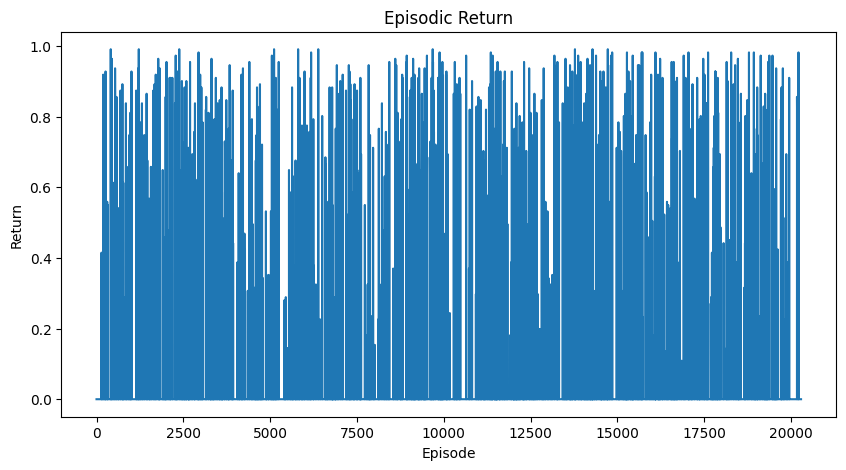

In [10]:
plt.figure(figsize=(10,5))
plt.plot(all_returns)
plt.title("Episodic Return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

### Sanity checks

In [11]:
for name, param in model.named_parameters():
    if torch.isnan(param).any():
        print(name, "contains NaNs")